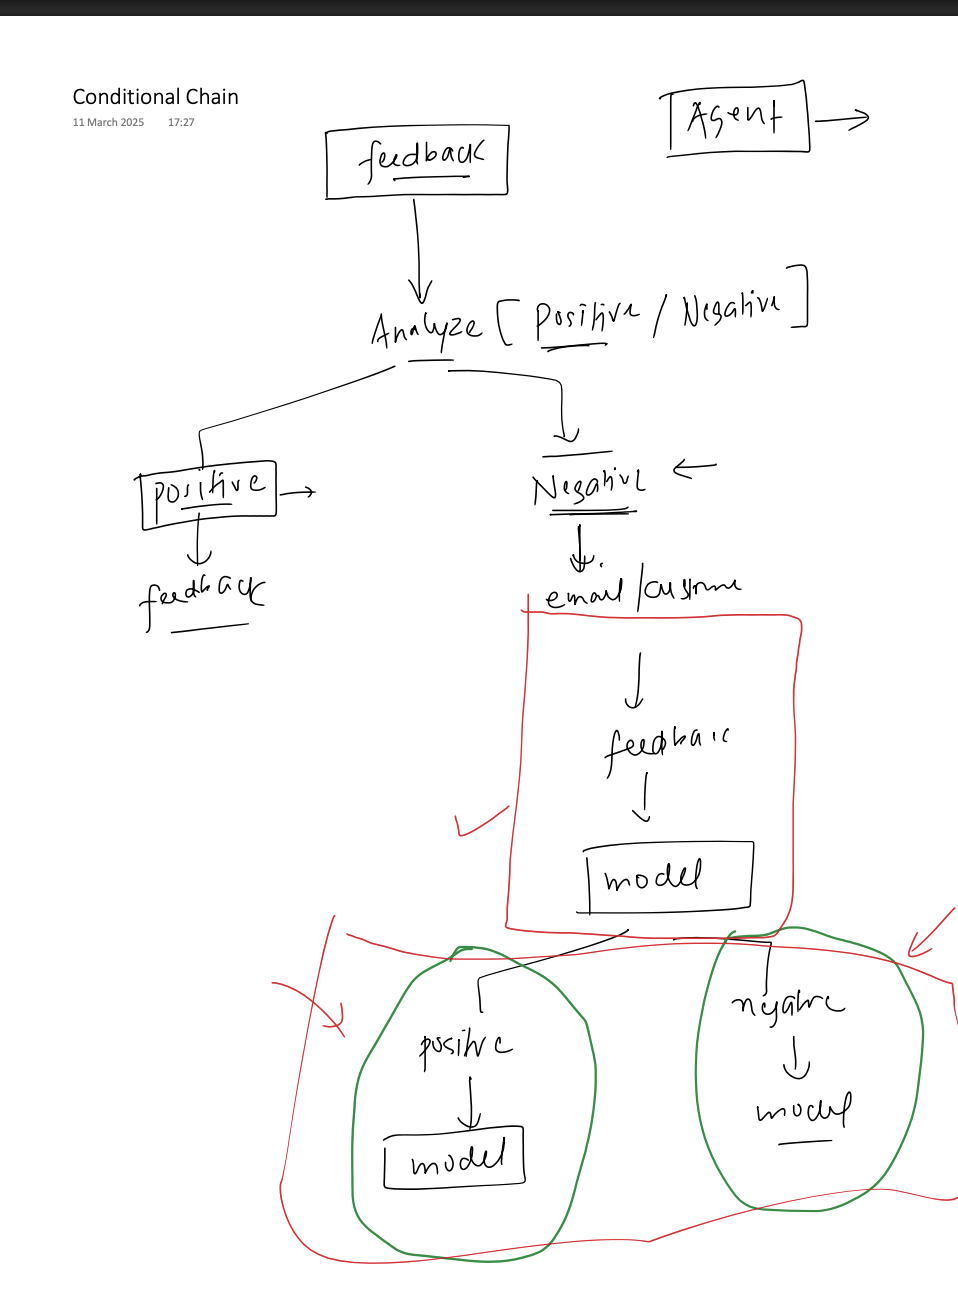

In this application, we classify customer feedback as positive or negative. Based on
the classification, we generate an appropriate response using a different prompt.
This demonstrates branching logic within a chain.
• Explanation:
1. Structured Output for Classification: To ensure the
classification is consistent ('positive' or 'negative'), we use a
PydanticOutputParser . We define a Feedback class with
a sentiment field that can only be these two values.
2. Classification Chain ( classifier_chain ): Takes the
feedback text, uses a prompt with format instructions from
the parser, calls the model, and uses the
PydanticOutputParser to get a structured Feedback
object.
3. Conditional Branching ( RunnableBranch ): This is the
core of the conditional chain.
▪ It evaluates conditions based on the output of
the classifier_chain (the x in the lambda
functions).
▪ Condition 1: If x.sentiment == "positive" ,
execute a chain ( positive_chain ) that thanks
the customer.
▪ Condition 2: If x.sentiment == "negative" ,
execute a different chain ( negative_chain )
that apologizes.
▪ Default: If neither condition is met (shouldn't
happen here), a fallback runnable (created with
RunnableLambda ) returns an error message.
4. Final Chain: The entire flow is classifier_chain |
branch_chain .

### Defining the pydantic model for Structured Output

In [1]:
from pydantic import BaseModel,Field
from typing import Literal,Annotated

class FeedBack(BaseModel):
    sentiment:Annotated[Literal["positive","negative"],Field(...,description="The sentiment of the feedback.")]

### define model and parsers

In [5]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
import os

# Load environment variables
load_dotenv()

api_key = os.getenv("Hugging_face_api_token")

# Create LLM endpoint
llm = HuggingFaceEndpoint(
    # repo_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation",
    huggingfacehub_api_token=api_key,
)

# Wrap with chat interface
model = ChatHuggingFace(llm=llm)

In [6]:
from langchain_core.output_parsers import PydanticOutputParser,StrOutputParser
pydantic_parser=PydanticOutputParser(pydantic_object=FeedBack)
str_parser=StrOutputParser()

### defining prompt tempalate

In [4]:
from langchain_core.prompts import PromptTemplate

#Prompt for Classification

classify_prompt=PromptTemplate(
    template="""Classify the sentiment of the following feedback text into 'positive' or 'negative'.\n Feedback:{feedback} \n {format_instruction}""",
    input_variables=["feedback"],
    partial_variables={
        "format_instruction":pydantic_parser.get_format_instructions()
    }
)

#prompt for positive response
positive_prompt=PromptTemplate(
    template="Write an appropriate thank you message for the positive feedback : {feedback}",
    input_variables=["feedback"]
)
# prompt for negative response
negative_prompt=PromptTemplate(
    template="Write an appropriate apologetic message for this negative feedback : {feedback}",
    input_variables=["feefeedback"]
)


### create chains and invoke

In [7]:
# classificaion chain
classifier_chain=classify_prompt|model|pydantic_parser

#chains for the branches
positive_chain=positive_prompt|model|str_parser
negative_chain=negative_prompt|model|str_parser



In [8]:
#Fall back chain (using Runnable Lambda to convert a function into a runnable)
from langchain_core.runnables import RunnableBranch, RunnableLambda
def default_response(x):
    return "Could not find sentiment"
fallback_chain=RunnableLambda(default_response)

# --- Create the Conditional Branch ---
# if-else statement of langchain universe
branch_chain=RunnableBranch(
    # (condition to check, which chain to run)
    # (default chain is also needed)
    (lambda x: x.sentiment == "positive",positive_chain),
    (lambda x:x.sentiment == "negative",negative_chain),
    fallback_chain # default chain if neither case worked

)


# --- Create the Final Chain ---
final_chain=classifier_chain|branch_chain

## invoke chain

In [9]:
# Example 1: Negative feedback
negative_feedback="This is a terrible phone."
result=final_chain.invoke({
    "feedback":negative_feedback
})

In [10]:
print(result)

 Subject: Re: Feedback Received Regarding Your Recent Interaction

Dear Valued Customer,

Thank you for taking the time to share your feedback with us. I am truly sorry that our interaction did not meet your expectations or provide the experience you were hoping for. I understand that negative feedback is an opportunity for us to learn and improve, and I will make sure that your concerns are brought to the attention of the appropriate team members.

We value your business and appreciate your patience as we work to address any issues that arose during our interaction. I would be happy to help answer any questions you may have or provide additional information if needed. Please do not hesitate to reach out to me directly at [your email address] or [your phone number].

Once again, I apologize for any inconvenience or frustration caused and am committed to making things right. Your satisfaction is our top priority, and we will work diligently to ensure that future interactions exceed your

In [11]:
# Example 2: Positive feedback
positive_feedback="This is a wonderful phone."
result=final_chain.invoke({
    "feedback":positive_feedback
})
print(result)

 Dear Valued Customer,

We are thrilled to hear that you had a positive experience with our product or service. Your kind feedback is a great encouragement for us and a testament to our team's dedication and hard work. We are always striving to provide the best possible experience for our customers and your positive sentiment reinforces that we are on the right track.

Thank you for taking the time to share your positive thoughts. We appreciate your business and look forward to serving you again in the future.

Best Regards,
[Your Company]


### Visualize the Output

In [12]:
final_chain.get_graph().print_ascii()

    +-------------+      
    | PromptInput |      
    +-------------+      
            *            
            *            
            *            
   +----------------+    
   | PromptTemplate |    
   +----------------+    
            *            
            *            
            *            
  +-----------------+    
  | ChatHuggingFace |    
  +-----------------+    
            *            
            *            
            *            
+----------------------+ 
| PydanticOutputParser | 
+----------------------+ 
            *            
            *            
            *            
       +--------+        
       | Branch |        
       +--------+        
            *            
            *            
            *            
    +--------------+     
    | BranchOutput |     
    +--------------+     
